# Константы, импорты

In [60]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, f1_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt

TARGET = "stroke"

DATASET_PATH = "./healthcare-dataset-stroke-data.xls"

numeric_cols = ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
numeric_cols_without_id = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Загрузка данных

In [61]:
df = pd.read_csv(DATASET_PATH)
print('Размер:', df.shape)
print(df[TARGET].value_counts())
df.head()

Размер: (5110, 12)
stroke
0    4861
1     249
Name: count, dtype: int64


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Анализ сырых данных

Анализ данных до преобразования категориальных признаков

## Базовый анализ, взгляд на данные

In [62]:
print('=== Типы данных, количество пропусков ===')
df.info()

=== Типы данных, количество пропусков ===
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [63]:
print('=== Статистика по числовым и категориальным признакам ===')
df.describe(include='all')

=== Статистика по числовым и категориальным признакам ===


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


In [64]:
print ('=== Количество уникальных значений по колонкам (категориальные колонки) ===')
for col in cat_cols:
    print(f'{col}: {df[col].nunique()}')

=== Количество уникальных значений по колонкам (категориальные колонки) ===
gender: 3
ever_married: 2
work_type: 5
Residence_type: 2
smoking_status: 4


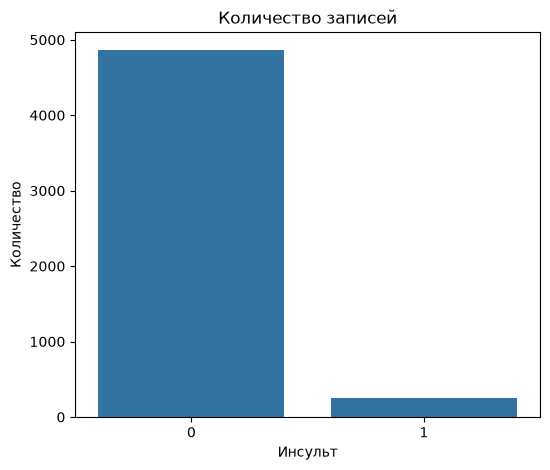

In [65]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x=TARGET)
plt.xlabel('Инсульт')
plt.ylabel('Количество')
plt.title('Количество записей')
plt.show()

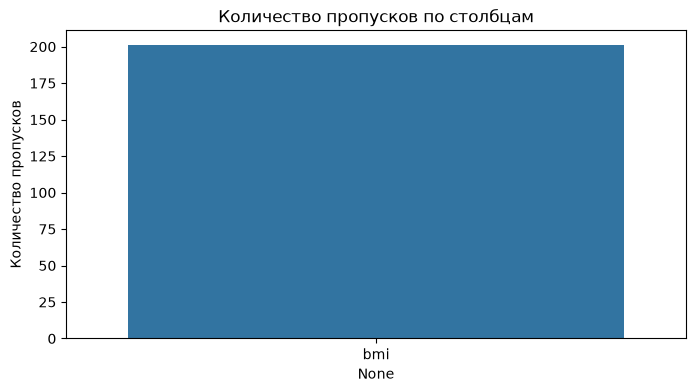

In [66]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)
plt.title('Количество пропусков по столбцам')
plt.ylabel('Количество пропусков')
plt.show()

## Анализ числовых признаков

### Анализ распределения (ящики с усами)

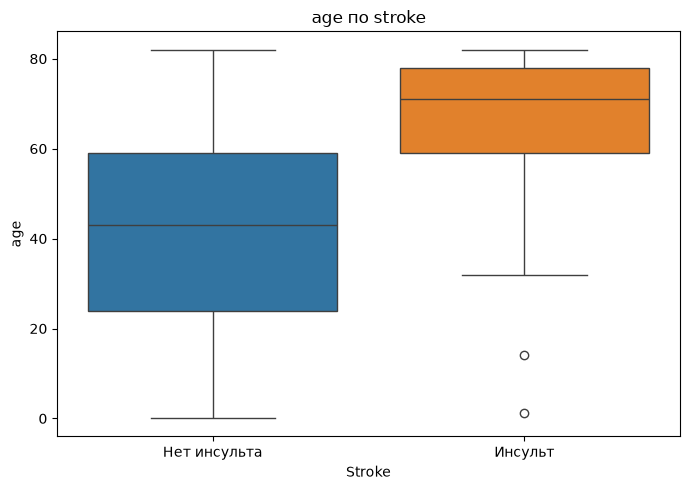


Распределение: age

Stroke = 0 (Нет инсульта)
  Количество:       4861
  Min:              0.08
  Q1 (25%):         24.00
  Median (50%):     43.00
  Q3 (75%):         59.00
  Max:              82.00
  IQR:              35.00
  Нижний ус:        0.08
  Верхний ус:       82.00
  Выбросов:         0

Stroke = 1 (Инсульт)
  Количество:       249
  Min:              1.32
  Q1 (25%):         59.00
  Median (50%):     71.00
  Q3 (75%):         78.00
  Max:              82.00
  IQR:              19.00
  Нижний ус:        32.00
  Верхний ус:       82.00
  Выбросов:         2


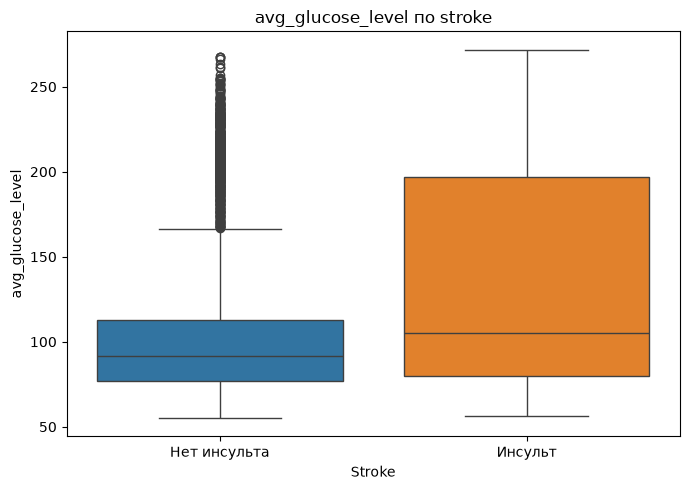


Распределение: avg_glucose_level

Stroke = 0 (Нет инсульта)
  Количество:       4861
  Min:              55.12
  Q1 (25%):         77.12
  Median (50%):     91.47
  Q3 (75%):         112.83
  Max:              267.76
  IQR:              35.71
  Нижний ус:        55.12
  Верхний ус:       166.38
  Выбросов:         551

Stroke = 1 (Инсульт)
  Количество:       249
  Min:              56.11
  Q1 (25%):         79.79
  Median (50%):     105.22
  Q3 (75%):         196.71
  Max:              271.74
  IQR:              116.92
  Нижний ус:        56.11
  Верхний ус:       271.74
  Выбросов:         0


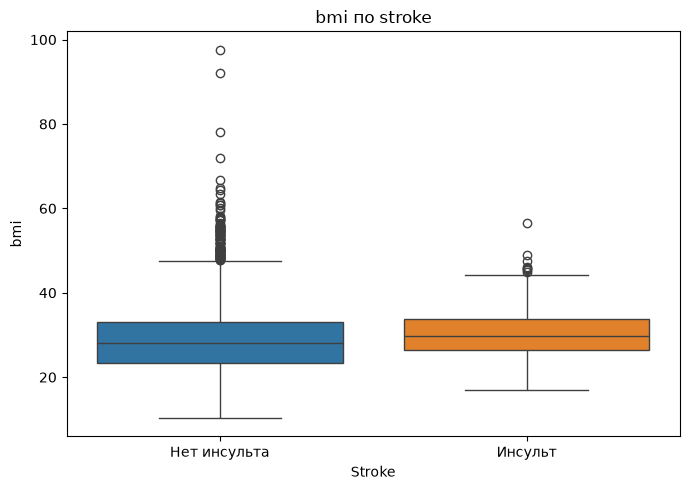


Распределение: bmi

Stroke = 0 (Нет инсульта)
  Количество:       4700
  Min:              10.30
  Q1 (25%):         23.40
  Median (50%):     28.00
  Q3 (75%):         33.10
  Max:              97.60
  IQR:              9.70
  Нижний ус:        10.30
  Верхний ус:       47.60
  Выбросов:         105

Stroke = 1 (Инсульт)
  Количество:       209
  Min:              16.90
  Q1 (25%):         26.40
  Median (50%):     29.70
  Q3 (75%):         33.70
  Max:              56.60
  IQR:              7.30
  Нижний ус:        16.90
  Верхний ус:       44.20
  Выбросов:         8


In [67]:
def plot_boxplots_with_statistics(df, columns, target='stroke'):
    for col in columns:
        plt.figure(figsize=(7, 5))

        # Boxplot
        sns.boxplot(
            data=df,
            x=target,
            y=col,
            hue=target,
            legend=False
        )

        plt.title(f'{col} по {target}')
        plt.xlabel('Stroke')
        plt.ylabel(col)
        plt.xticks(
            [0, 1],
            ['Нет инсульта', 'Инсульт']
        )

        plt.tight_layout()
        plt.show()

        # Числовое представление
        print(f'\n{"=" * 50}')
        print(f'Распределение: {col}')
        print(f'{"=" * 50}')

        for stroke_value in sorted(df[target].dropna().unique()):

            values = df.loc[
                df[target] == stroke_value,
                col
            ].dropna()

            q1 = values.quantile(0.25)
            median = values.quantile(0.50)
            q3 = values.quantile(0.75)

            iqr = q3 - q1

            lower_limit = q1 - 1.5 * iqr
            upper_limit = q3 + 1.5 * iqr

            # Фактические границы усов
            lower_whisker = values[
                values >= lower_limit
            ].min()

            upper_whisker = values[
                values <= upper_limit
            ].max()

            # Выбросы
            outliers = values[
                (values < lower_limit) |
                (values > upper_limit)
            ]

            print(
                f'\nStroke = {stroke_value} '
                f'({"Нет инсульта" if stroke_value == 0 else "Инсульт"})'
            )

            print(f'  Количество:       {len(values)}')
            print(f'  Min:              {values.min():.2f}')
            print(f'  Q1 (25%):         {q1:.2f}')
            print(f'  Median (50%):     {median:.2f}')
            print(f'  Q3 (75%):         {q3:.2f}')
            print(f'  Max:              {values.max():.2f}')
            print(f'  IQR:              {iqr:.2f}')
            print(f'  Нижний ус:        {lower_whisker:.2f}')
            print(f'  Верхний ус:       {upper_whisker:.2f}')
            print(f'  Выбросов:         {len(outliers)}')
    
plot_boxplots_with_statistics(df, ['age', 'avg_glucose_level', 'bmi'])

### Анализ бинарных признаков

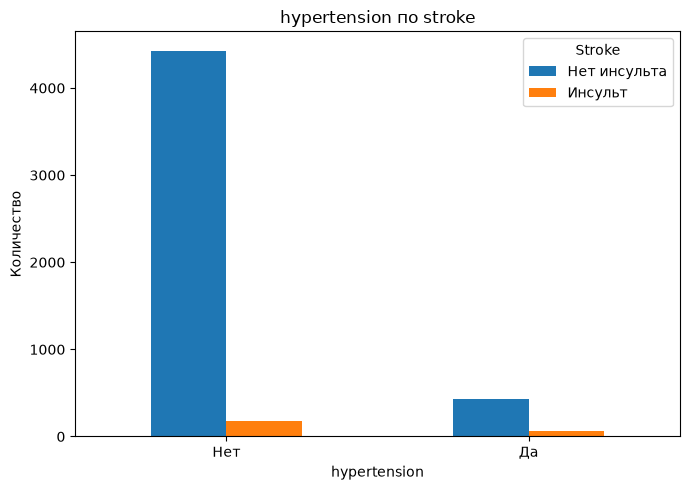


hypertension

hypertension = 0
  Всего:              4612
  Без инсульта:       4429
  С инсультом:        183
  Доля инсульта:      3.97%

hypertension = 1
  Всего:              498
  Без инсульта:       432
  С инсультом:        66
  Доля инсульта:      13.25%


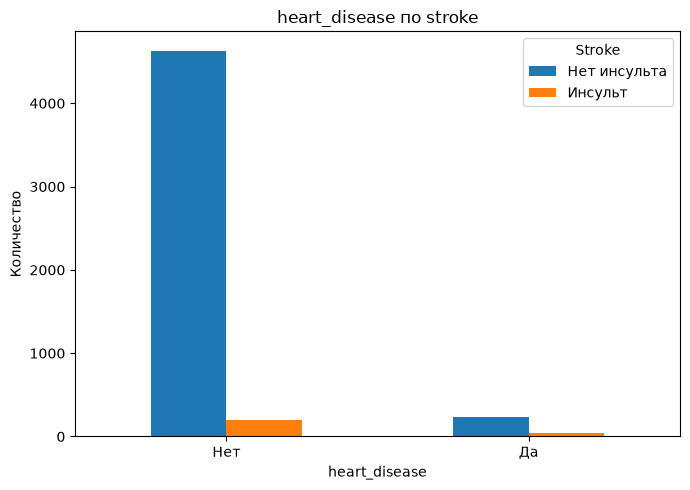


heart_disease

heart_disease = 0
  Всего:              4834
  Без инсульта:       4632
  С инсультом:        202
  Доля инсульта:      4.18%

heart_disease = 1
  Всего:              276
  Без инсульта:       229
  С инсультом:        47
  Доля инсульта:      17.03%


In [68]:
def plot_binary_by_stroke(df, columns, target='stroke'):
    for col in columns:
        counts = (
            df.groupby([col, target])
            .size()
            .unstack(fill_value=0)
        )

        # График
        counts.plot(
            kind='bar',
            figsize=(7, 5)
        )

        plt.title(f'{col} по {target}')
        plt.xlabel(col)
        plt.ylabel('Количество')
        plt.xticks(
            [0, 1],
            ['Нет', 'Да'],
            rotation=0
        )
        plt.legend(
            ['Нет инсульта', 'Инсульт'],
            title='Stroke'
        )
        plt.tight_layout()
        plt.show()

        print(f'\n{"=" * 50}')
        print(f'{col}')
        print(f'{"=" * 50}')

        for value in sorted(df[col].dropna().unique()):
            subset = df[df[col] == value]

            total = len(subset)
            strokes = subset[target].sum()
            stroke_rate = strokes / total * 100

            print(f'\n{col} = {value}')
            print(f'  Всего:              {total}')
            print(f'  Без инсульта:       {(subset[target] == 0).sum()}')
            print(f'  С инсультом:        {strokes}')
            print(f'  Доля инсульта:      {stroke_rate:.2f}%')
            
plot_binary_by_stroke(
    df,
    ['hypertension', 'heart_disease']
)

### Анализ распределения (Skewness)

In [69]:
from scipy.stats import skew
print(df[numeric_cols].apply(skew))

id                  -0.019907
age                 -0.137019
hypertension         2.714595
heart_disease        3.946085
avg_glucose_level    1.571822
bmi                       NaN
dtype: float64


### Анализ выбросов

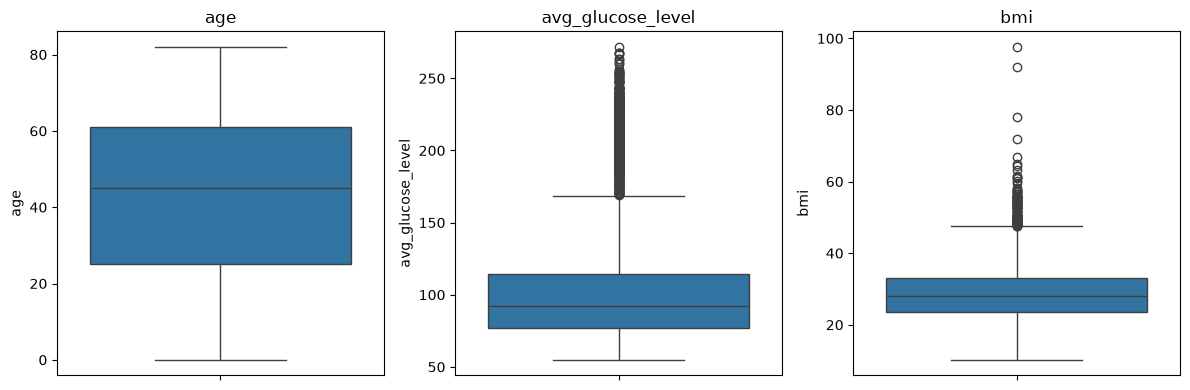

In [70]:
plt.figure(figsize=(12,4))
num_cols = ['age', 'avg_glucose_level', 'bmi']
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Анализ категориальных признаков

### Столбчатые диаграммы для категориальных признаков

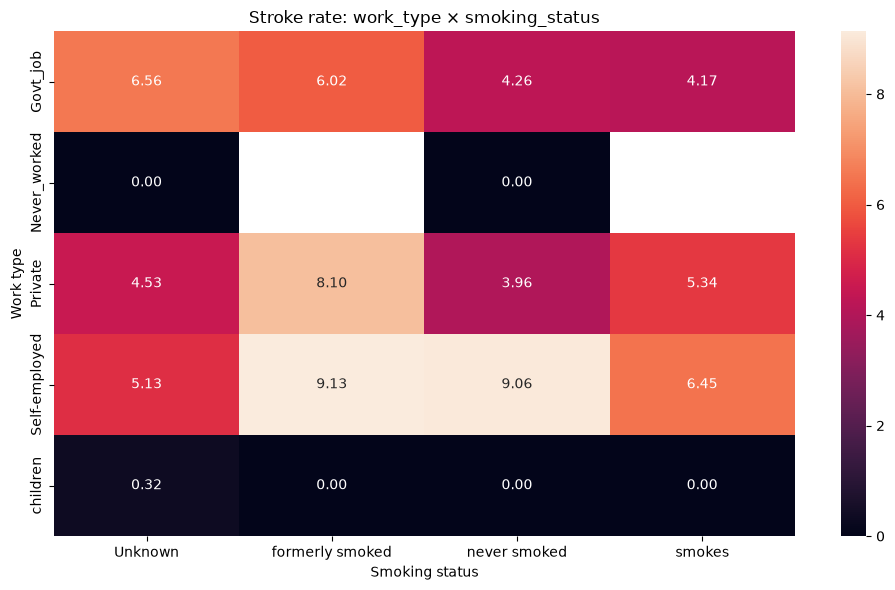

In [71]:
table = pd.pivot_table(
    df,
    values='stroke',
    index='work_type',
    columns='smoking_status',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    table,
    annot=True,
    fmt='.2f'
)

plt.title('Stroke rate: work_type × smoking_status')
plt.xlabel('Smoking status')
plt.ylabel('Work type')
plt.tight_layout()
plt.show()

# Подготовка данных. Преобразование категориальных признаков

In [72]:
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].replace([np.inf, -np.inf], np.nan)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['smoking_status'] = df['smoking_status'].fillna(df['smoking_status'].mode()[0])

X = df.drop(TARGET, axis=1)
y = df[TARGET]

label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

C:\Users\Aleksei\AppData\Local\Temp\ipykernel_6112\1075967024.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


# Анализ данных после преобразования

## HeatMap параметров

Топ-10 признаков, наиболее коррелирующих с stroke:
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
ever_married         0.108340
bmi                  0.036110
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
id                   0.006388
Name: stroke, dtype: float64


C:\Users\Aleksei\AppData\Local\Temp\ipykernel_6112\1811237343.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


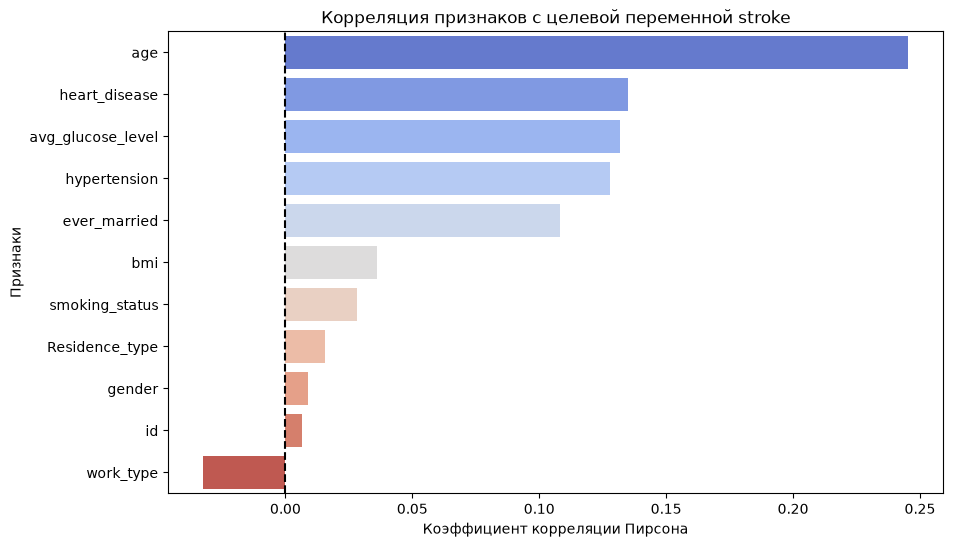

In [73]:
df_encoded = X.copy()
df_encoded[TARGET] = y

corr = df_encoded.corr()

corr_with_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)

print(f"Топ-10 признаков, наиболее коррелирующих с {TARGET}:")
print(corr_with_target.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Корреляция признаков с целевой переменной ' + TARGET)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.ylabel('Признаки')
plt.axvline(0, color='black', linestyle='--')
plt.show()

# Feature Engineering

На предыдущем шаге стали известны параметры, которые более всего влияют на сигнал Stroke. На основе этой информации можно вывести новые признаки

In [74]:
def create_features(df):
    df = df.copy()
    
    df['age_group'] = pd.cut(df['age'], bins=[0, 40, 55, 65, 75, 120], 
                             labels=[0, 1, 2, 3, 4])
    df['is_elderly'] = (df['age'] >= 65).astype(int)
    df['age_squared'] = df['age'] ** 2
    
    df['age_hypertension'] = df['age'] * df['hypertension']
    df['age_heart_disease'] = df['age'] * df['heart_disease']
    df['age_glucose'] = df['age'] * df['avg_glucose_level']
    df['age_bmi'] = df['age'] * df['bmi']
    
    df['high_glucose'] = (df['avg_glucose_level'] > 140).astype(int)
    df['very_high_glucose'] = (df['avg_glucose_level'] > 200).astype(int)
    df['glucose_group'] = pd.cut(df['avg_glucose_level'], 
                                 bins=[0, 100, 140, 200, 300], 
                                 labels=[0, 1, 2, 3])
    
    df['bmi_group'] = pd.cut(df['bmi'], 
                             bins=[0, 18.5, 25, 30, 35, 100], 
                             labels=[0, 1, 2, 3, 4])
    df['is_obese'] = (df['bmi'] >= 30).astype(int)
    df['is_overweight'] = (df['bmi'] >= 25).astype(int)
    
    df['risk_score'] = (df['hypertension'] + 
                        df['heart_disease'] + 
                        df['is_obese'] + 
                        df['high_glucose'] + 
                        df['is_elderly'])
    
    df['cardio_risk'] = df['hypertension'] + df['heart_disease']
        
    return df

# Разделение данных на тренировочную и тестовую выборки

In [75]:
X_enhanced = create_features(X)
# Удаляем id, gender, Residence_type т.к. они почти не коррелируют со 
X_enhanced = X_enhanced.drop(['id', 'gender', 'Residence_type'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=1610, stratify=y
)

### SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=1610)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

### Корелляция после Feature Engineering

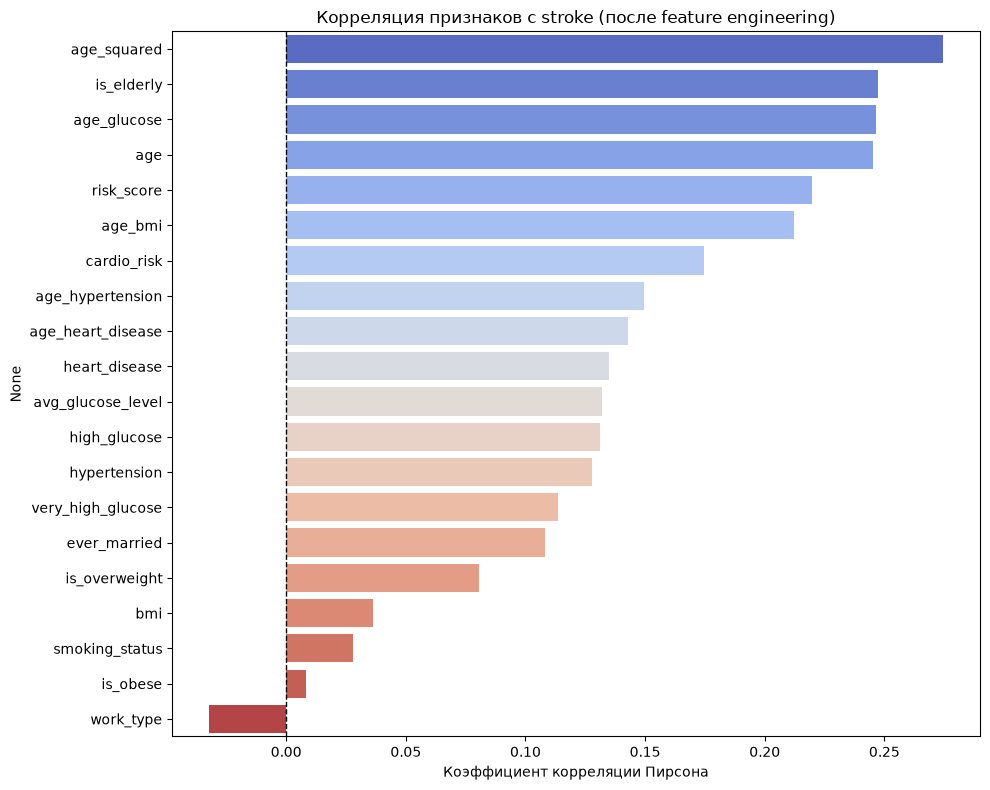

Топ-15 признаков:
age_squared          0.274620
is_elderly           0.247136
age_glucose          0.246558
age                  0.245257
risk_score           0.219739
age_bmi              0.212057
cardio_risk          0.174616
age_hypertension     0.149634
age_heart_disease    0.142783
heart_disease        0.134914
avg_glucose_level    0.131945
high_glucose         0.131171
hypertension         0.127904
very_high_glucose    0.113633
ever_married         0.108340
Name: stroke, dtype: float64


In [77]:
df_for_corr = X_enhanced.copy()
df_for_corr[TARGET] = y

corr = df_for_corr.corr(numeric_only=True)

corr_with_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=corr_with_target.values, 
    y=corr_with_target.index, 
    hue=corr_with_target.index,   # чтобы не было предупреждения
    palette='coolwarm',
    legend=False
)
plt.title('Корреляция признаков с stroke (после feature engineering)')
plt.xlabel('Коэффициент корреляции Пирсона')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("Топ-15 признаков:")
print(corr_with_target.head(15))

# Обучение модели

## Поиск лучших параметров

In [78]:
neg, pos = np.bincount(y_train_res)
scale = neg / pos

"""param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [scale, scale*2, scale*3, 15, 20]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=1610, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)"""
#grid_xgb.fit(X_train_res, y_train_res)
model = XGBClassifier(random_state=1610, 
                      eval_metric='logloss',
                      colsample_bytree=0.7,
                      learning_rate=0.05,
                      max_depth=8,
                      n_estimators=200,
                      min_sample_split=2,
                      min_samples_leaf=4,)
model.fit(X_train_res, y_train_res)
#print("Лучшие параметры XGBoost:", grid_xgb.best_params_)

d:\Projects\ML_Stroke_Prediction\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:35:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "min_sample_split", "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Index(['age', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'avg_glucose_level', 'bmi', 'smoking_status', 'age_group', 'is_elderly',
       'age_squared', 'age_hypertension', 'age_heart_disease', 'age_glucose',
       'age_bmi', 'high_glucose', 'very_high_glucose', 'glucose_group',
       'bmi_group', 'is_obese', 'is_overweight', 'risk_score', 'cardio_risk'],
      dtype='str')
[0.07797555 0.02269683 0.03802669 0.03382823 0.03061759 0.02651244
 0.02712408 0.02743107 0.05042533 0.27306208 0.08731119 0.03304194
 0.02926429 0.02780119 0.04172241 0.01878312 0.04363522 0.02175923
 0.02060059 0.00596415 0.01866786 0.02219546 0.0215534 ]


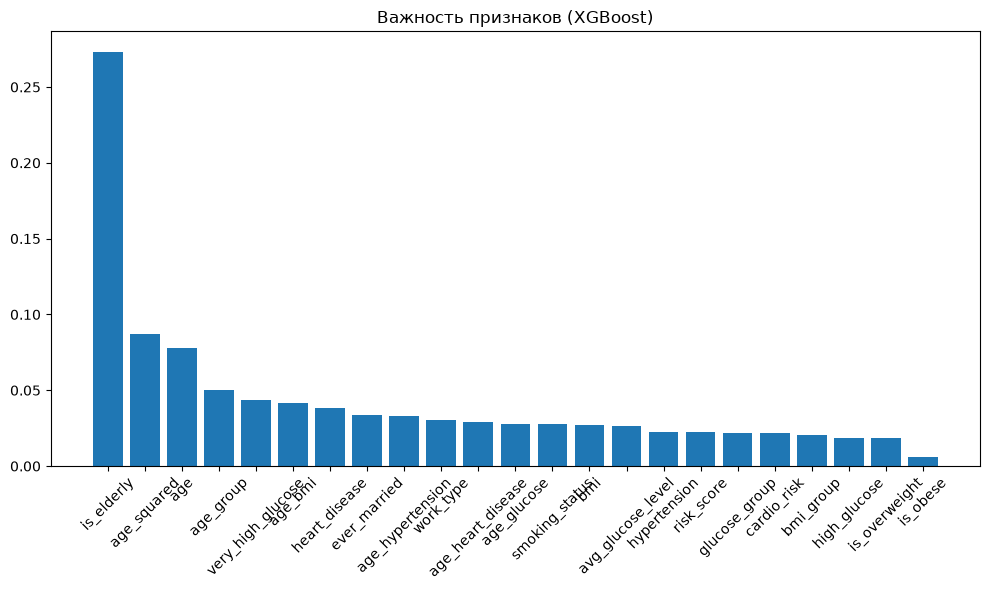

In [79]:
importances = model.feature_importances_
feature_names = X_enhanced.columns
indices = np.argsort(importances)[::-1]

print(feature_names)
print(importances)

plt.figure(figsize=(10,6))
plt.title("Важность признаков (XGBoost)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

## Предсказываем

In [86]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
best_f1 = 0
best_f05 = 0
best_f2 = 0
best_thr_f1 = 0.5
best_thr_f05 = 0.5
best_thr_f2 = 0.5

for thr in thresholds:
    y_tmp = (y_pred_proba >= thr).astype(int)
    f1 = f1_score(y_test, y_tmp)
    f2 = fbeta_score(y_test, y_tmp, beta=2)
    f05 = fbeta_score(y_test, y_tmp, beta=0.5)
    if f1 > best_f1:
        best_f1 = f1
        best_thr_f1 = thr
    if f2 > best_f2:
        best_f2 = f2
        best_thr_f2 = thr
    if f05 > best_f05:
        best_f05 = f05
        best_thr_f05 = thr

print(f"Оптимальный порог по F1:   {best_thr_f1:.2f} (F1={best_f1:.3f})")
print(f"Оптимальный порог по F2:   {best_thr_f2:.2f} (F2={best_f2:.3f})")
print(f"Оптимальный порог по F0.5: {best_thr_f05:.2f} (F0.5={best_f05:.3f})")

y_pred = (y_pred_proba >= best_thr_f1).astype(int)

Оптимальный порог по F1:   0.23 (F1=0.194)
Оптимальный порог по F2:   0.13 (F2=0.237)
Оптимальный порог по F0.5: 0.23 (F0.5=0.203)


# Оценка качества

In [81]:
def print_metrics_explained(y_true, y_pred, target_names):
    """
    Печатает краткое объяснение метрик классификации.
    """

    report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    acc = report['accuracy']
    
    print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}% правильных ответов)")
    
    for name in target_names:
        m = report[name]
        print(f"\nКласс '{name}':")
        print(f"  precision = {m['precision']:.2f}  ({m['precision']*100:.0f}% предсказанных верны)")
        print(f"  recall    = {m['recall']:.2f}    ({m['recall']*100:.0f}% реальных найдены)")
        print(f"  f1-score  = {m['f1-score']:.2f}")
    
    macro = report['macro avg']
    weighted = report['weighted avg']
    print("\nСредние:")
    print(f"  macro avg    precision={macro['precision']:.2f}, recall={macro['recall']:.2f}, f1={macro['f1-score']:.2f}")
    print(f"  weighted avg precision={weighted['precision']:.2f}, recall={weighted['recall']:.2f}, f1={weighted['f1-score']:.2f}")

In [87]:
print_metrics_explained(y_test, y_pred, ['Нет инсульта', 'Инсульт'])

Accuracy: 0.9266  (92.66% правильных ответов)

Класс 'Нет инсульта':
  precision = 0.96  (96% предсказанных верны)
  recall    = 0.97    (97% реальных найдены)
  f1-score  = 0.96

Класс 'Инсульт':
  precision = 0.21  (21% предсказанных верны)
  recall    = 0.18    (18% реальных найдены)
  f1-score  = 0.19

Средние:
  macro avg    precision=0.58, recall=0.57, f1=0.58
  weighted avg precision=0.92, recall=0.93, f1=0.92


# График "Предсказание VS Реальность"

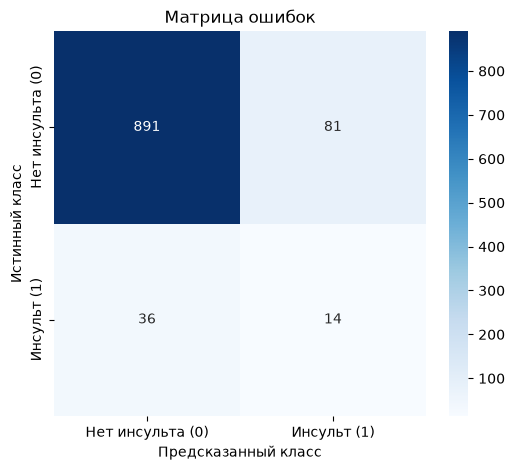

In [83]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Нет инсульта (0)', 'Инсульт (1)'],
            yticklabels=['Нет инсульта (0)', 'Инсульт (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

In [84]:
def plot_class_metrics(y_true, y_pred, target_names):
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        output_dict=True
    )

    metrics = ['precision', 'recall', 'f1-score']

    values_0 = [
        report[target_names[0]]['precision'],
        report[target_names[0]]['recall'],
        report[target_names[0]]['f1-score']
    ]

    values_1 = [
        report[target_names[1]]['precision'],
        report[target_names[1]]['recall'],
        report[target_names[1]]['f1-score']
    ]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(8, 5))

    plt.bar(x - width/2, values_0, width, label=target_names[0])
    plt.bar(x + width/2, values_1, width, label=target_names[1])

    plt.xticks(x, metrics)
    plt.ylabel('Значение')
    plt.ylim(0, 1)
    plt.title('Метрики классификации по классам')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
def plot_real_vs_predicted(y_true, y_pred):
    real_counts = np.bincount(y_true)
    pred_counts = np.bincount(y_pred)

    x = np.arange(2)
    width = 0.35

    plt.figure(figsize=(7, 5))

    plt.bar(
        x - width/2,
        real_counts,
        width,
        label='Реальные'
    )

    plt.bar(
        x + width/2,
        pred_counts,
        width,
        label='Предсказанные'
    )

    plt.xticks(
        x,
        ['Нет инсульта', 'Инсульт']
    )

    plt.ylabel('Количество')
    plt.title('Реальное и предсказанное распределение классов')
    plt.legend()

    plt.tight_layout()
    plt.show()

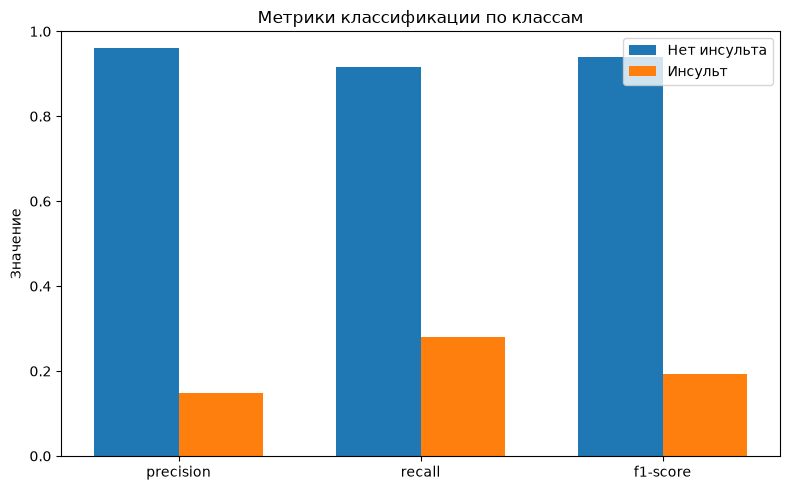

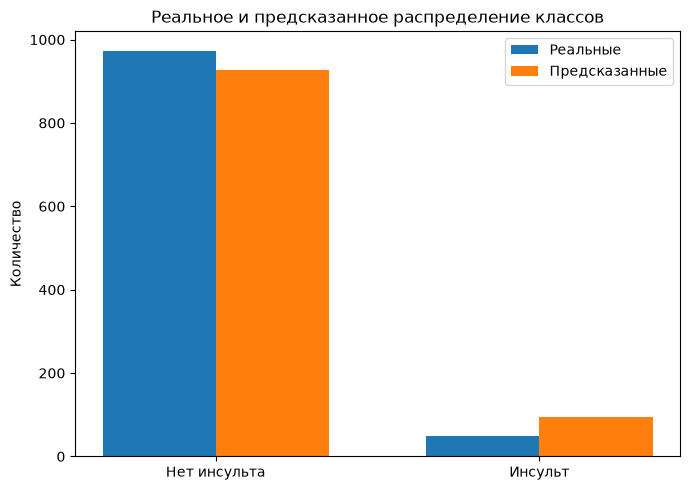

In [85]:
plot_class_metrics(
    y_test,
    y_pred,
    ['Нет инсульта', 'Инсульт']
)

plot_real_vs_predicted(y_test, y_pred)